In [5]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import smarts_cerebellum.globals as gl

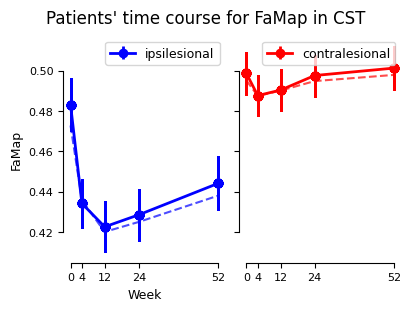

In [6]:
lme = pd.read_csv(os.path.join(gl.baseDir, 'lme', f'patients_JHU_MNI_FaMap_CST_lme.tsv'), sep = '\t')
lme['Week'] = lme['Week'].astype(int)
lme = lme.sort_values('Week')

# observed values
obs = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'JHU_MNI_DTI_flip.tsv'), sep = '\t', low_memory = False)
obs = obs[obs.metric == 'FaMap']

controls = ['CUP_1001', 'CUP_1002', 'JHP_1001', 'JHP_1002', 'JHP_1004']
obs = obs[~obs.subj_id.isin(controls)]

# ipsilesional = right, since all lesions are flipped to the right
fig, axs = plt.subplots(1,2, figsize=(4,3), sharey = True, constrained_layout=True)

lme_ipsi = lme[(lme.regionname == 'CST_R')].sort_values('Week')
lme_contra = lme[(lme.regionname == 'CST_L')].sort_values('Week')

obs_ipsi = obs[obs.regionname == 'CST_R'].groupby('Week')['mean'].mean().reset_index()
obs_contra = obs[obs.regionname == 'CST_L'].groupby('Week')['mean'].mean().reset_index()

axs[0].errorbar(x = lme_ipsi['Week'], y = lme_ipsi['beta'], yerr = lme_ipsi['se'], fmt = '-o', linewidth = 2, color = 'blue', label = 'ipsilesional')
axs[1].errorbar(x = lme_contra['Week'], y = lme_contra['beta'], yerr = lme_contra['se'], fmt = '-o', linewidth = 2, color = 'red', label = 'contralesional')

axs[0].plot(obs_ipsi['Week'], obs_ipsi['mean'], alpha = .7, linestyle = '--', color = 'blue')
axs[1].plot(obs_contra['Week'], obs_contra['mean'], alpha = .7, linestyle = '--', color = 'red')

for ax in axs:
    ax.legend()
    ax.set_xticks(gl.weeks)
    axs[0].set_ylabel('FaMap')
    axs[0].set_xlabel("Week")


plt.suptitle(f"Patients' time course for FaMap in CST")
sns.despine(trim = True)
plt.show()

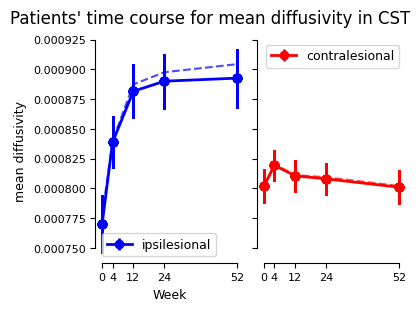

In [7]:
lme = pd.read_csv(os.path.join(gl.baseDir, 'lme', f'patients_JHU_MNI_mean_diffusivity_CST_lme.tsv'), sep = '\t')
lme['Week'] = lme['Week'].astype(int)
lme = lme.sort_values('Week')

# observed values
obs = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'JHU_MNI_DTI_flip.tsv'), sep = '\t', low_memory = False)
obs = obs[obs.metric == 'mean_diffusivity']

controls = ['CUP_1001', 'CUP_1002', 'JHP_1001', 'JHP_1002', 'JHP_1004']
obs = obs[~obs.subj_id.isin(controls)]

# ipsilesional = right, since all lesions are flipped to the right
fig, axs = plt.subplots(1,2, figsize=(4,3), sharey = True, constrained_layout=True)

lme_ipsi = lme[(lme.regionname == 'CST_R')].sort_values('Week')
lme_contra = lme[(lme.regionname == 'CST_L')].sort_values('Week')

obs_ipsi = obs[obs.regionname == 'CST_R'].groupby('Week')['mean'].mean().reset_index()
obs_contra = obs[obs.regionname == 'CST_L'].groupby('Week')['mean'].mean().reset_index()

axs[0].errorbar(x = lme_ipsi['Week'], y = lme_ipsi['beta'], yerr = lme_ipsi['se'], fmt = '-o', linewidth = 2, color = 'blue', label = 'ipsilesional')
axs[1].errorbar(x = lme_contra['Week'], y = lme_contra['beta'], yerr = lme_contra['se'], fmt = '-o', linewidth = 2, color = 'red', label = 'contralesional')

axs[0].plot(obs_ipsi['Week'], obs_ipsi['mean'], alpha = .7, linestyle = '--', color = 'blue')
axs[1].plot(obs_contra['Week'], obs_contra['mean'], alpha = .7, linestyle = '--', color = 'red')

for ax in axs:
    ax.legend()
    ax.set_xticks(gl.weeks)
    axs[0].set_ylabel('mean diffusivity')
    axs[0].set_xlabel("Week")


plt.suptitle(f"Patients' time course for mean diffusivity in CST")
sns.despine(trim = True)
plt.show()

In [10]:
# RADIAL DIFFUSIVITY
lme_rd = pd.read_csv(os.path.join(gl.baseDir, 'lme', f'patients_JHU_MNI_radial_diffusivity_CST_lme.tsv'), sep = '\t')
lme_rd['Week'] = lme_rd['Week'].astype(int)
lme_rd = lme_rd.sort_values('Week')

# observed values
obs_rd = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'JHU_MNI_DTI_flip.tsv'), sep = '\t', low_memory = False)
obs_rd = obs_rd[obs_rd.metric == 'radial_diffusivity']
controls = ['CUP_1001', 'CUP_1002', 'JHP_1001', 'JHP_1002', 'JHP_1004']
obs_rd = obs_rd[~obs_rd.subj_id.isin(controls)]

lme_ipsi_rd = lme_rd[(lme_rd.regionname == 'CST_R')].sort_values('Week')
lme_contra_rd = lme_rd[(lme_rd.regionname == 'CST_L')].sort_values('Week')

obs_ipsi_rd = obs_rd[obs_rd.regionname == 'CST_R'].groupby('Week')['mean'].mean().reset_index()
obs_contra_rd = obs_rd[obs_rd.regionname == 'CST_L'].groupby('Week')['mean'].mean().reset_index()


# EIGENVALUE 1
lme_eig1 = pd.read_csv(os.path.join(gl.baseDir, 'lme', f'patients_JHU_MNI_lambda_1_CST_lme.tsv'), sep = '\t')
lme_eig1['Week'] = lme_eig1['Week'].astype(int)
lme_eig1 = lme_eig1.sort_values('Week')

# observed values
obs_eig1 = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'JHU_MNI_DTI_flip.tsv'), sep = '\t', low_memory = False)
obs_eig1 = obs_eig1[obs_eig1.metric == 'lambda_1']
controls = ['CUP_1001', 'CUP_1002', 'JHP_1001', 'JHP_1002', 'JHP_1004']
obs_eig1 = obs_eig1[~obs_eig1.subj_id.isin(controls)]


lme_ipsi_eig1 = lme_eig1[(lme_eig1.regionname == 'CST_R')].sort_values('Week')
lme_contra_eig1 = lme_eig1[(lme_eig1.regionname == 'CST_L')].sort_values('Week')

obs_ipsi_eig1 = obs_eig1[obs_eig1.regionname == 'CST_R'].groupby('Week')['mean'].mean().reset_index()
obs_contra_eig1 = obs_eig1[obs_eig1.regionname == 'CST_L'].groupby('Week')['mean'].mean().reset_index()

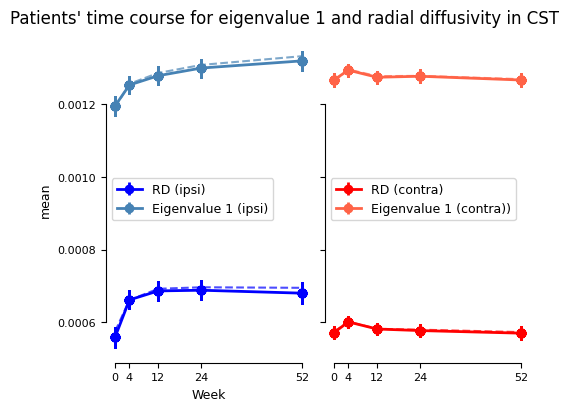

In [9]:
# ipsilesional = right, since all lesions are flipped to the right
fig, axs = plt.subplots(1,2, figsize=(5, 4), sharey = True, constrained_layout=True)

axs[0].errorbar(x = lme_ipsi_rd['Week'], y = lme_ipsi_rd['beta'], yerr = lme_ipsi_rd['se'], fmt = '-o', linewidth = 2, color = 'blue', label = 'RD (ipsi)')
axs[1].errorbar(x = lme_contra_rd['Week'], y = lme_contra_rd['beta'], yerr = lme_contra_rd['se'], fmt = '-o', linewidth = 2, color = 'red', label = 'RD (contra)')

axs[0].plot(obs_ipsi_rd['Week'], obs_ipsi_rd['mean'], alpha = .7, linestyle = '--', color = 'blue')
axs[1].plot(obs_contra_rd['Week'], obs_contra_rd['mean'], alpha = .7, linestyle = '--', color = 'red')

axs[0].errorbar(x = lme_ipsi_eig1['Week'], y = lme_ipsi_eig1['beta'], yerr = lme_ipsi_eig1['se'], fmt = '-o', linewidth = 2, color = 'steelblue', label = 'Eigenvalue 1 (ipsi)')
axs[1].errorbar(x = lme_contra_eig1['Week'], y = lme_contra_eig1['beta'], yerr = lme_contra_eig1['se'], fmt = '-o', linewidth = 2, color = 'tomato', label = 'Eigenvalue 1 (contra))')

axs[0].plot(obs_ipsi_eig1['Week'], obs_ipsi_eig1['mean'], alpha = .7, linestyle = '--', color = 'steelblue')
axs[1].plot(obs_contra_eig1['Week'], obs_contra_eig1['mean'], alpha = .7, linestyle = '--', color = 'tomato')


for ax in axs:
    ax.legend(loc = 'center left')
    ax.set_xticks(gl.weeks)
    axs[0].set_ylabel('mean')
    axs[0].set_xlabel("Week")


plt.suptitle(f"Patients' time course for eigenvalue 1 and radial diffusivity in CST")
sns.despine(trim = True)
plt.show()

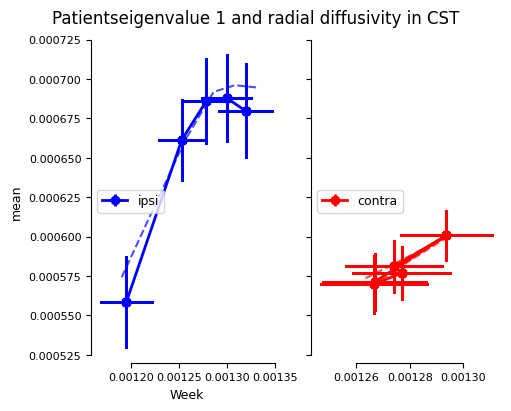

In [57]:
# plot eigenvalue 1 against radial diffusivity
fig, axs = plt.subplots(1, 2, figsize = (5,4), sharey = True, constrained_layout = True)
axs[0].errorbar(x = lme_ipsi_eig1['beta'], y = lme_ipsi_rd['beta'], xerr = lme_ipsi_eig1['se'], yerr = lme_ipsi_rd['se'], fmt = '-o', linewidth = 2, color = 'blue', label = 'ipsi')
axs[1].errorbar(x = lme_contra_eig1['beta'], y = lme_contra_rd['beta'], xerr = lme_contra_eig1['se'], yerr = lme_contra_rd['se'], fmt = '-o', linewidth = 2, color = 'red', label = 'contra')

axs[0].plot(obs_ipsi_eig1['mean'], obs_ipsi_rd['mean'], alpha = .7, linestyle = '--', color = 'blue')
axs[1].plot(obs_contra_eig1['mean'], obs_contra_rd['mean'], alpha = .7, linestyle = '--', color = 'red')

for ax in axs:
    ax.legend(loc = 'center left')
    axs[0].set_ylabel('mean')
    axs[0].set_xlabel("Week")

plt.suptitle(f"Patientseigenvalue 1 and radial diffusivity in CST")
sns.despine(trim = True)
plt.show()